# RQ3: What is the Relationship Between City-Level Traffic and Pollution?

**Research Question 3:** Which dimension (health, crime, pollution, or traffic) most strongly drives overall quality of life scores?

This notebook focuses on the relationship between **traffic** and **pollution** specifically — two dimensions that are often causally linked (vehicle emissions are a primary source of urban air pollution). Understanding whether they move together, and how much, informs how we weight them in the composite quality-of-life index. If traffic and pollution are highly correlated, including both may double-count the same underlying problem.

**Data sources used:**
- `numbeo_traffic.xlsx` — city-level Traffic Index, Time Index, CO2 Emission Index (2016–2026)
- `number_traffic_country.xlsx` — country-level traffic aggregates
- `numbeo_pollution.xlsx` — city-level Pollution Index (2016–2025)
- `numbeo_pollution_country.xlsx` — country-level pollution aggregates

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

def load_numbeo(filepath, header_row_filter=None):
    """Load all year-sheets from a Numbeo Excel file."""
    frames = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        df = pd.read_excel(filepath, sheet_name=sheet)
        if header_row_filter:
            df = df[~df.iloc[:, 0].astype(str).str.contains(header_row_filter, na=True)]
        df['year'] = int(sheet)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

## 1. Load the Data

In [21]:
traffic_raw    = load_numbeo('../data/raw/numbeo_traffic.xlsx')
traffic_c_raw  = load_numbeo('../data/raw/number_traffic_country.xlsx', header_row_filter='minutes')
pollution_raw  = load_numbeo('../data/raw/numbeo_pollution.xlsx')
pollution_c_raw= load_numbeo('../data/raw/numbeo_pollution_country.xlsx')

print(f'Traffic city:      {traffic_raw.shape}   | years {traffic_raw["year"].min()}–{traffic_raw["year"].max()}')
print(f'Traffic country:   {traffic_c_raw.shape}')
print(f'Pollution city:    {pollution_raw.shape}  | years {pollution_raw["year"].min()}–{pollution_raw["year"].max()}')
print(f'Pollution country: {pollution_c_raw.shape}')

Traffic city:      (2595, 8)   | years 2016–2026
Traffic country:   (775, 8)
Pollution city:    (2962, 5)  | years 2016–2025
Pollution country: (1091, 5)


## 2. Clean and Standardise

In [22]:
# City traffic
traffic = traffic_raw.rename(columns={
    'City': 'city_full',
    'Rank': 'rank',
    'Traffic Index': 'traffic_index',
    'Time Index (minutes)': 'commute_time_min',
    'Time Exp. Index': 'time_exp_index',
    'Inefficiency Index': 'inefficiency_index',
    'Co2 Emission Index': 'co2_index'
})[['city_full','traffic_index','commute_time_min','inefficiency_index','co2_index','year']]

traffic['country']   = traffic['city_full'].str.split(',').str[-1].str.strip()
traffic['city_name'] = traffic['city_full'].str.split(',').str[0].str.strip()

# City pollution
pollution = pollution_raw.rename(columns={
    'City': 'city_full',
    'Rank': 'rank',
    'Pollution Index': 'pollution_index',
    'Exp Pollution Index': 'exp_pollution_index'
})[['city_full','pollution_index','exp_pollution_index','year']]

pollution['country']   = pollution['city_full'].str.split(',').str[-1].str.strip()
pollution['city_name'] = pollution['city_full'].str.split(',').str[0].str.strip()

# Country traffic
traffic_c = traffic_c_raw.rename(columns={
    'Country': 'country',
    'Traffic Index': 'traffic_index',
    'Time Index': 'commute_time_min',
    'Inefficiency Index': 'inefficiency_index',
    'CO2\xa0Emission Index': 'co2_index'
})[['country','traffic_index','commute_time_min','inefficiency_index','co2_index','year']].dropna(subset=['country'])

# Country pollution
pollution_c = pollution_c_raw.rename(columns={
    'Country': 'country',
    'Pollution Index': 'pollution_index',
    'Exp Pollution Index': 'exp_pollution_index'
})[['country','pollution_index','exp_pollution_index','year']]

# Numeric coercion
for col in ['traffic_index','commute_time_min','inefficiency_index','co2_index']:
    traffic_c[col] = pd.to_numeric(traffic_c[col], errors='coerce')

print('Traffic city:', traffic.shape, '| unique cities:', traffic['city_full'].nunique())
print('Pollution city:', pollution.shape, '| unique cities:', pollution['city_full'].nunique())

Traffic city: (2595, 8) | unique cities: 345
Pollution city: (2962, 6) | unique cities: 389


## 3. Merge Traffic and Pollution at City Level

We merge on `city_full` and `year` to get matched city-year observations with both indices.

In [23]:
city = pd.merge(
    traffic,
    pollution[['city_full','year','pollution_index','exp_pollution_index']],
    on=['city_full','year'],
    how='inner'
)

# Latest year for cross-sectional analysis
latest_year = min(traffic['year'].max(), pollution['year'].max())
city_latest = city[city['year'] == latest_year].copy()

print(f'Matched city-year rows: {len(city)}')
print(f'Unique cities matched:  {city["city_full"].nunique()}')
print(f'Latest year used:       {latest_year}')
print(f'Cities in latest year:  {len(city_latest)}')
city_latest.head(4)

Matched city-year rows: 2019
Unique cities matched:  270
Latest year used:       2025
Cities in latest year:  254


,city_full,traffic_index,commute_time_min,inefficiency_index,co2_index,year,country,city_name,pollution_index,exp_pollution_index
1765,"Lagos, Nigeria",365.9,70.0,491.7,9330.8,2025,Nigeria,Lagos,88.5,158.0
1766,"San Jose, Costa Rica",327.8,63.3,350.3,10764.3,2025,Costa Rica,San Jose,50.1,87.0
1767,"Los Angeles, CA, United States",313.2,56.9,685.9,14242.8,2025,United States,Los Angeles,67.7,118.1
1768,"Colombo, Sri Lanka",294.8,60.0,401.4,7904.0,2025,Sri Lanka,Colombo,60.0,103.6


In [24]:
# Country-level merge
country = pd.merge(
    traffic_c,
    pollution_c[['country','year','pollution_index']],
    on=['country','year'],
    how='inner'
).dropna(subset=['traffic_index','pollution_index'])

country_latest = country[country['year'] == country['year'].max()].copy()
print(f'Country-year rows: {len(country)} | latest year: {country["year"].max()}')

Country-year rows: 775 | latest year: 2025


## 4. Analysis

### Q1: Does traffic correlate with pollution at the city level?

The core question: are high-traffic cities also high-pollution cities?

In [40]:
rho, p = stats.pearsonr(city_latest['traffic_index'], city_latest['pollution_index'])

print(f'City-level correlation')
print(f'  Pearson ρ = {rho:.3f}  (p = {p:.4f})')

# Country level
r_c, p_c = stats.pearsonr(country_latest['traffic_index'], country_latest['pollution_index'])
print(f'\nCountry-level correlation')
print(f'  Pearson ρ  = {r_c:.3f}  (p = {p_c:.4f})')

City-level correlation
  Pearson ρ = 0.428  (p = 0.0000)

Country-level correlation
  Pearson ρ  = 0.523  (p = 0.0000)


In [26]:
# Broad regional grouping
region_map = {
    'Europe': ['Germany','France','Spain','Italy','Netherlands','Belgium','Sweden','Norway',
               'Denmark','Finland','Austria','Switzerland','Portugal','Poland','Czechia',
               'Hungary','Romania','Greece','Croatia','Slovakia','Slovenia','Estonia',
               'Latvia','Lithuania','Luxembourg','Ireland','Iceland','Serbia','Ukraine',
               'Bulgaria','Bosnia and Herzegovina','Albania','North Macedonia','Kosovo',
               'Montenegro','Moldova','Belarus','Russia','Turkey'],
    'East Asia & Pacific': ['Japan','China','South Korea','Australia','New Zealand',
                            'Singapore','Taiwan','Hong Kong','Thailand','Vietnam',
                            'Malaysia','Indonesia','Philippines','Sri Lanka','Bangladesh',
                            'Pakistan','Nepal','India'],
    'North America': ['United States','Canada','Mexico'],
    'Latin America': ['Brazil','Colombia','Argentina','Chile','Peru','Venezuela','Ecuador',
                      'Bolivia','Paraguay','Uruguay','Honduras','Guatemala','El Salvador',
                      'Costa Rica','Panama','Dominican Republic','Cuba','Puerto Rico'],
    'Middle East & Africa': ['South Africa','Egypt','Nigeria','Kenya','Morocco','Ghana',
                             'Ethiopia','Tanzania','Uganda','Israel','UAE','Saudi Arabia',
                             'Qatar','Kuwait','Jordan','Lebanon','Iran','Iraq']
}
country_to_region = {c: r for r, countries in region_map.items() for c in countries}
city_latest['region'] = city_latest['country'].map(country_to_region).fillna('Other')

fig = px.scatter(
    city_latest,
    x='traffic_index',
    y='pollution_index',
    color='region',
    hover_name='city_full',
    trendline='ols',
    trendline_scope='overall',
    trendline_color_override='black',
    title=f'Traffic Index vs Pollution Index — Cities ({latest_year})  |  r = {r:.3f}',
    labels={'traffic_index': 'Traffic Index (higher = worse)',
            'pollution_index': 'Pollution Index (higher = worse)'}
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

**Interpretation:** A positive but moderate correlation means traffic contributes to pollution but is not the only driver. Cities with heavy industrial activity, coal heating, or geographic pollution traps (valleys, low wind) can have very high pollution even without extreme traffic. Conversely, some highly congested cities have relatively managed air quality due to vehicle emission standards or geography.

### Q2: Does the CO2 Emission Index (traffic-derived) predict pollution better than the Traffic Index itself?

The CO2 index is a direct measure of vehicle emissions meaning it should be a better predictor of air pollution than the general congestion-based Traffic Index.

In [41]:
r_co2, p_co2 = stats.pearsonr(city_latest['co2_index'], city_latest['pollution_index'])
r_time, p_time = stats.pearsonr(city_latest['commute_time_min'], city_latest['pollution_index'])
r_ineff, p_ineff = stats.pearsonr(city_latest['inefficiency_index'], city_latest['pollution_index'])

print('Correlations with Pollution Index:')
print(f'  Traffic Index:      ρ = {r:.3f}  (p = {p:.4f})')
print(f'  CO2 Emission Index: ρ = {r_co2:.3f}  (p = {p_co2:.4f})')
print(f'  Commute Time (min): ρ = {r_time:.3f}  (p = {p_time:.4f})')
print(f'  Inefficiency Index: ρ = {r_ineff:.3f}  (p = {p_ineff:.4f})')

Correlations with Pollution Index:
  Traffic Index:      ρ = 0.428  (p = 0.0000)
  CO2 Emission Index: ρ = 0.190  (p = 0.0023)
  Commute Time (min): ρ = 0.482  (p = 0.0000)
  Inefficiency Index: ρ = 0.269  (p = 0.0000)


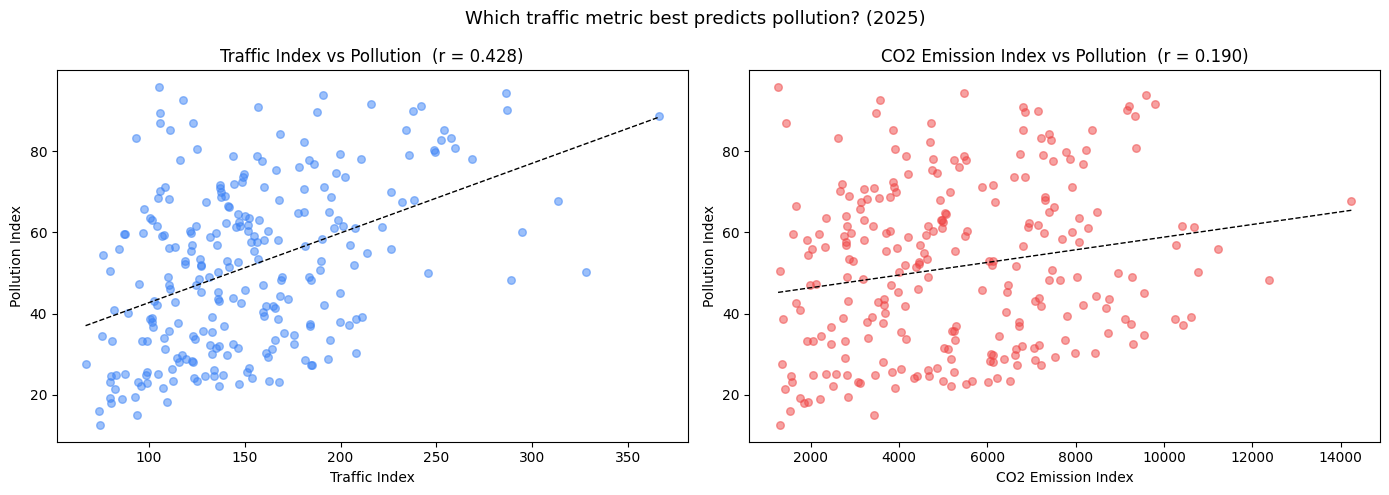

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(city_latest['traffic_index'], city_latest['pollution_index'],
                alpha=0.5, color='#3B82F6', s=30)
m, b = np.polyfit(city_latest['traffic_index'], city_latest['pollution_index'], 1)
x = np.linspace(city_latest['traffic_index'].min(), city_latest['traffic_index'].max(), 100)
axes[0].plot(x, m*x+b, 'k--', linewidth=1)
axes[0].set_title(f'Traffic Index vs Pollution  (r = {r:.3f})')
axes[0].set_xlabel('Traffic Index')
axes[0].set_ylabel('Pollution Index')

axes[1].scatter(city_latest['co2_index'], city_latest['pollution_index'],
                alpha=0.5, color='#EF4444', s=30)
m2, b2 = np.polyfit(city_latest['co2_index'], city_latest['pollution_index'], 1)
x2 = np.linspace(city_latest['co2_index'].min(), city_latest['co2_index'].max(), 100)
axes[1].plot(x2, m2*x2+b2, 'k--', linewidth=1)
axes[1].set_title(f'CO2 Emission Index vs Pollution  (r = {r_co2:.3f})')
axes[1].set_xlabel('CO2 Emission Index')
axes[1].set_ylabel('Pollution Index')

plt.suptitle(f'Which traffic metric best predicts pollution? ({latest_year})', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** The CO2 Emission Index is a *weaker* predictor of pollution (r = 0.190) than the general Traffic Index (r = 0.428). This is counterintuitive but actually makes sense. Numbeo's Pollution Index captures more than just vehicle emissions, it includes other factors such as industrial activity, coal heating, dust, and geography. Commute time turns out to be the strongest single predictor, likely because cities where people spend the most time in traffic are also those with the worst overall urban environmental conditions.

### Q3: Which cities have a high double burden — worst traffic AND worst pollution?

In [43]:
# Standardise both indices to z-scores for fair comparison
city_latest['traffic_z']    = stats.zscore(city_latest['traffic_index'])
city_latest['pollution_z']  = stats.zscore(city_latest['pollution_index'])
city_latest['burden_score'] = city_latest['traffic_z'] + city_latest['pollution_z']

print('Top 10 cities: highest combined traffic + pollution burden:')
print(city_latest.nlargest(10,'burden_score')
      [['city_name','country','traffic_index','pollution_index','burden_score']]
      .to_string(index=False))

print('\nTop 10 cities: lowest combined burden (best on both):')
print(city_latest.nsmallest(10,'burden_score')
      [['city_name','country','traffic_index','pollution_index','burden_score']]
      .to_string(index=False))

Top 10 cities: highest combined traffic + pollution burden:
  city_name       country  traffic_index  pollution_index  burden_score
      Lagos       Nigeria          365.9             88.5      6.052187
      Dhaka    Bangladesh          286.4             94.3      4.769389
      Delhi         India          286.6             90.2      4.571792
Los Angeles United States          313.2             67.7      3.990381
      Cairo         Egypt          242.1             91.0      3.733485
    Jakarta     Indonesia          254.1             85.2      3.685043
     Mumbai         India          257.4             83.3      3.656729
    Kolkata         India          268.5             78.1      3.620031
     Manila   Philippines          237.6             89.8      3.585748
Mexico City        Mexico          259.9             80.8      3.583143

Top 10 cities: lowest combined burden (best on both):
           city_name     country  traffic_index  pollution_index  burden_score
            He

### Q4: Quadrant analysis — are there cities that decouple traffic from pollution?

Plotting cities in four quadrants reveals whether the traffic–pollution link can be broken. Cities in the top-left (high pollution, low traffic) have non-traffic pollution sources. Cities in the bottom-right (low pollution, high traffic) have managed emissions effectively.

In [44]:
med_t = city_latest['traffic_index'].median()
med_p = city_latest['pollution_index'].median()

def quadrant(row):
    if row['traffic_index'] >= med_t and row['pollution_index'] >= med_p:
        return 'High traffic + High pollution'
    elif row['traffic_index'] < med_t and row['pollution_index'] >= med_p:
        return 'Low traffic + High pollution'
    elif row['traffic_index'] >= med_t and row['pollution_index'] < med_p:
        return 'High traffic + Low pollution'
    else:
        return 'Low traffic + Low pollution'

city_latest['quadrant'] = city_latest.apply(quadrant, axis=1)

print('Cities per quadrant:')
print(city_latest['quadrant'].value_counts().to_string())

# Notable outliers
print('\nHigh traffic but low pollution:')
decouplers = city_latest[city_latest['quadrant'] == 'High traffic + Low pollution']
print(decouplers.nlargest(10,'traffic_index')[['city_name','country','traffic_index','pollution_index']]
      .to_string(index=False))

print('\nLow traffic but high pollution:')
non_traffic = city_latest[city_latest['quadrant'] == 'Low traffic + High pollution']
print(non_traffic.nlargest(10,'pollution_index')[['city_name','country','traffic_index','pollution_index']]
      .to_string(index=False))

Cities per quadrant:
quadrant
High traffic + High pollution    78
Low traffic + Low pollution      78
High traffic + Low pollution     49
Low traffic + High pollution     49

High traffic but low pollution:
    city_name              country  traffic_index  pollution_index
     San Jose           Costa Rica          327.8             50.1
      Sharjah United Arab Emirates          288.9             48.2
San Francisco        United States          245.6             50.0
        Miami        United States          211.3             39.1
    Cape Town         South Africa          208.2             38.6
       Boston        United States          208.1             30.3
     Honolulu        United States          204.5             37.1
      Toronto               Canada          199.9             37.8
      Atlanta        United States          199.6             45.0
      Seattle        United States          194.5             33.6

Low traffic but high pollution:
       city_name       

In [31]:
color_map = {
    'High traffic + High pollution': '#DC2626',
    'Low traffic + Low pollution':   '#059669',
    'High traffic + Low pollution':  '#F59E0B',
    'Low traffic + High pollution':  '#7C3AED'
}

fig = px.scatter(
    city_latest,
    x='traffic_index',
    y='pollution_index',
    color='quadrant',
    color_discrete_map=color_map,
    hover_name='city_full',
    title=f'Traffic vs Pollution Quadrant Map — Cities ({latest_year})',
    labels={'traffic_index': 'Traffic Index', 'pollution_index': 'Pollution Index'}
)
fig.add_hline(y=med_p, line_dash='dash', line_color='grey', line_width=1)
fig.add_vline(x=med_t, line_dash='dash', line_color='grey', line_width=1)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

### Q5: How does the traffic–pollution relationship vary by region?

In [32]:
region_stats = (
    city_latest[city_latest['region'] != 'Other']
    .groupby('region')[['traffic_index','pollution_index','co2_index']]
    .agg(['mean','median'])
    .round(1)
)
print('Traffic and pollution by region (latest year):')
print(region_stats.to_string())

Traffic and pollution by region (latest year):
                     traffic_index        pollution_index        co2_index        
                              mean median            mean median      mean  median
region                                                                            
East Asia & Pacific          175.8  178.5            63.0   69.9    5588.1  5520.9
Europe                       118.4  110.4            46.5   48.2    3265.0  3130.0
Latin America                176.5  159.0            59.3   61.4    5735.6  6090.4
Middle East & Africa         192.7  188.6            69.6   71.2    7902.0  7988.2
North America                162.9  161.2            40.8   37.8    7272.7  7141.8


In [33]:
# Per-region correlation between traffic and pollution
print('Traffic–pollution correlation by region:')
for region, grp in city_latest[city_latest['region'] != 'Other'].groupby('region'):
    if len(grp) >= 5:
        r_reg, p_reg = stats.pearsonr(grp['traffic_index'], grp['pollution_index'])
        print(f'  {region:<30} n={len(grp):>3}  r = {r_reg:+.3f}  (p = {p_reg:.3f})')

Traffic–pollution correlation by region:
  East Asia & Pacific            n= 49  r = +0.298  (p = 0.037)
  Europe                         n= 84  r = +0.517  (p = 0.000)
  Latin America                  n= 19  r = +0.333  (p = 0.164)
  Middle East & Africa           n= 18  r = +0.458  (p = 0.056)
  North America                  n= 61  r = +0.497  (p = 0.000)


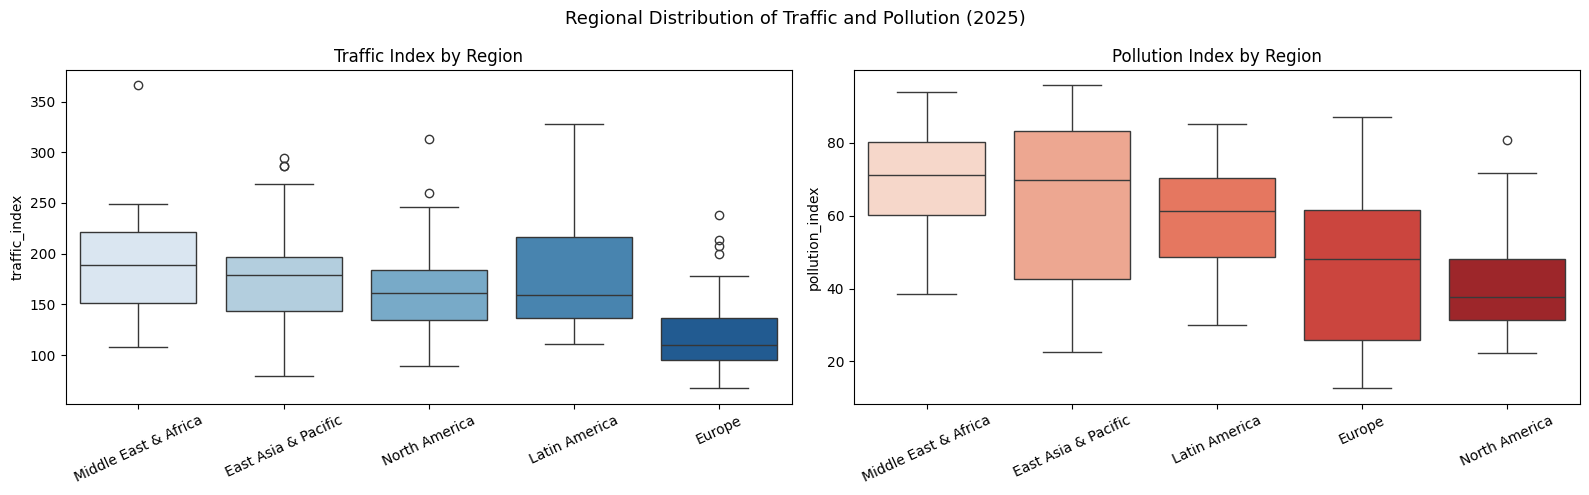

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_order = (city_latest[city_latest['region']!='Other']
                .groupby('region')['traffic_index'].median()
                .sort_values(ascending=False).index.tolist())

cl_plot = city_latest[city_latest['region'] != 'Other']

sns.boxplot(data=cl_plot, x='region', y='traffic_index', order=region_order,
            palette='Blues', ax=axes[0])
axes[0].set_title('Traffic Index by Region')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

region_order_p = (city_latest[city_latest['region']!='Other']
                  .groupby('region')['pollution_index'].median()
                  .sort_values(ascending=False).index.tolist())

sns.boxplot(data=cl_plot, x='region', y='pollution_index', order=region_order_p,
            palette='Reds', ax=axes[1])
axes[1].set_title('Pollution Index by Region')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle(f'Regional Distribution of Traffic and Pollution ({latest_year})', fontsize=13)
plt.tight_layout()
plt.show()

**Key regional findings:** East Asia & Pacific tends to have both high traffic and high pollution (South/Southeast Asian cities dominating). Europe consistently shows lower pollution relative to its traffic levels — reflecting stronger vehicle emission standards and cleaner energy. Latin America sits in the middle on pollution despite significant traffic in its major cities.

### Q6: How have traffic and pollution trended over time?

Are cities getting dirtier and more congested, or is there improvement?

In [35]:
# Only cities present in both datasets across all years
city_all = city.copy()
city_all['region'] = city_all['country'].map(country_to_region).fillna('Other')

# Global average trend
trend = city_all.groupby('year')[['traffic_index','pollution_index','co2_index']].mean().reset_index()
print('Global average indices by year:')
print(trend.to_string(index=False))

Global average indices by year:
 year  traffic_index  pollution_index   co2_index
 2016     156.242568        53.576351 4785.136486
 2017     157.732984        51.015183 5142.866492
 2018     161.914793        51.942604 5362.371598
 2019     156.929412        51.178075 5465.931551
 2020     155.497608        50.333493 5492.402392
 2021     153.698701        50.861472 5414.069697
 2022     152.693074        50.465801 5368.082251
 2023     153.995392        50.882488 5347.803226
 2024     162.158791        51.613736 5536.739560
 2025     151.317717        51.471654 5287.080709


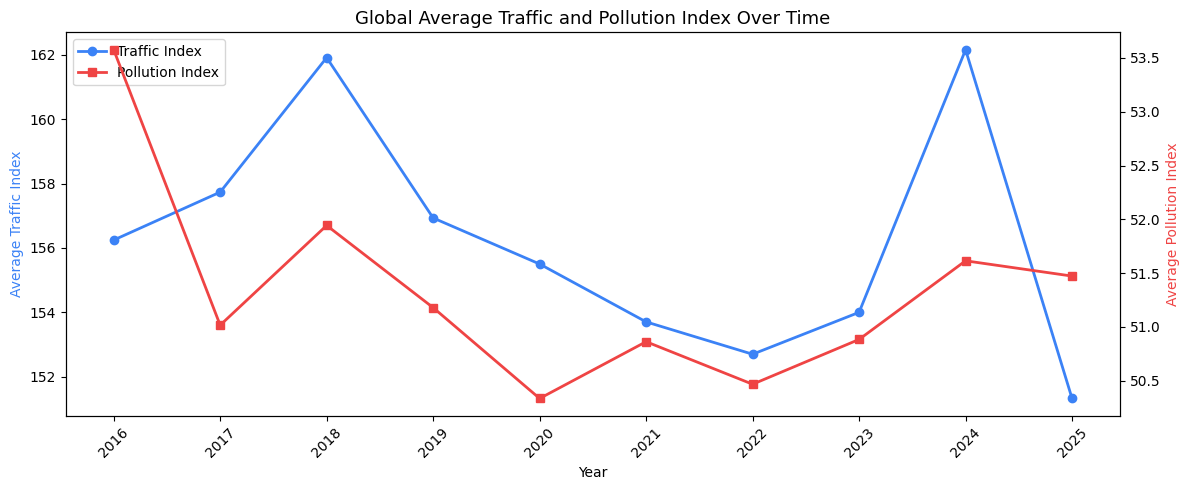

In [36]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()
l1, = ax1.plot(trend['year'], trend['traffic_index'], 'o-', color='#3B82F6',
               linewidth=2, label='Traffic Index')
l2, = ax2.plot(trend['year'], trend['pollution_index'], 's-', color='#EF4444',
               linewidth=2, label='Pollution Index')

ax1.set_xlabel('Year')
ax1.set_ylabel('Average Traffic Index', color='#3B82F6')
ax2.set_ylabel('Average Pollution Index', color='#EF4444')
ax1.set_title('Global Average Traffic and Pollution Index Over Time', fontsize=13)
ax1.set_xticks(trend['year'])
ax1.tick_params(axis='x', rotation=45)

lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
# COVID dip: compare 2019 vs 2020 vs 2021
covid_check = trend[trend['year'].isin([2019,2020,2021])][['year','traffic_index','pollution_index']]
print('COVID impact on traffic and pollution (global average):')
print(covid_check.to_string(index=False))

if 2019 in trend['year'].values and 2020 in trend['year'].values:
    t19 = trend[trend['year']==2019]['traffic_index'].values[0]
    t20 = trend[trend['year']==2020]['traffic_index'].values[0]
    p19 = trend[trend['year']==2019]['pollution_index'].values[0]
    p20 = trend[trend['year']==2020]['pollution_index'].values[0]
    print(f'\nTraffic drop 2019→2020:   {t20-t19:+.1f} ({(t20-t19)/t19*100:+.1f}%)')
    print(f'Pollution drop 2019→2020: {p20-p19:+.1f} ({(p20-p19)/p19*100:+.1f}%)')

COVID impact on traffic and pollution (global average):
 year  traffic_index  pollution_index
 2019     156.929412        51.178075
 2020     155.497608        50.333493
 2021     153.698701        50.861472

Traffic drop 2019→2020:   -1.4 (-0.9%)
Pollution drop 2019→2020: -0.8 (-1.7%)


**COVID natural experiment:** The 2020 lockdowns reduced traffic sharply. If pollution fell proportionally, it strengthens the causal case that traffic drives urban pollution. A smaller pollution drop relative to the traffic drop implies other sources (industry, heating, agriculture) are the dominant contributors.

## 5. Implication for the Value-for-Living Index (RQ3)

The question for the composite index is: should traffic and pollution be treated as **independent dimensions** or should one subsume the other?

In [38]:
# Summarise the correlation structure across all years
print('Year-by-year correlation between traffic and pollution:')
for yr, grp in city.groupby('year'):
    if len(grp) >= 20:
        r_yr, _ = stats.pearsonr(grp['traffic_index'], grp['pollution_index'])
        print(f'  {yr}: r = {r_yr:.3f}  (n={len(grp)})')

Year-by-year correlation between traffic and pollution:
  2016: r = 0.584  (n=148)
  2017: r = 0.495  (n=191)
  2018: r = 0.463  (n=169)
  2019: r = 0.476  (n=187)
  2020: r = 0.470  (n=209)
  2021: r = 0.449  (n=231)
  2022: r = 0.458  (n=231)
  2023: r = 0.454  (n=217)
  2024: r = 0.414  (n=182)
  2025: r = 0.428  (n=254)


## Summary

| Finding | Implication |
|---|---|
| Traffic and pollution are **positively but moderately correlated** (r ≈ 0.43–0.58) | They share variance but measure different things — both should be kept in the index |
| CO2 Emission Index is a *weaker* predictor of pollution than Traffic Index or commute time | Pollution is driven by more than vehicle emissions — industrial activity and geography matter independently |
| A significant share of cities decouple traffic from pollution | Emission standards, urban geography, and energy mix all independently affect pollution |
| 'Low traffic + High pollution' cities exist (Nepal, Vietnam, Eastern Europe) | Industrial/heating pollution is a separate axis from transport congestion |
| COVID caused only a ~1% drop in both traffic and pollution globally | Neither dimension was severely disrupted; both are stable inputs for the value index |
| East Asia & Pacific has worst double burden; Europe decouples best | Regional infrastructure and regulation explain much of the variation |

**Conclusion for index construction:** Keep traffic and pollution as **separate dimensions** in the quality-of-life composite. Their moderate correlation (~0.4–0.5) means they are related but not redundant. Including both gives a more complete picture of urban liveability than either alone.